# Solution for exercise 7.16
***

In [5]:
#Loading packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from ISLP import load_data

In [8]:
Wage = load_data('Wage')
Wage.head()

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


In [11]:
#Split dataframe
age = Wage['age']
wage = Wage['wage']

## a)
***

In [ ]:
#Split data
rng = np.random.default_rng(123)
n = len(Wage)

train_idx = rng.choice(n, size = n // 2, replace = False)
test_idx = np.setdiff1d(np.arange(n), train_idx)

train = Wage.iloc[train_idx]
test = Wage.iloc[test_idx]

In [ ]:
# #Alternative way of splitting data
# np.random.seed(123)
# n = len(Wage)

# train_idx = np.random.choice(n, size = n // 2, replace = False)

# train = Wage.iloc[train_idx]
# test = Wage.drop(train_idx)

In [23]:
#Polynomial function
def polyreg(k, data):
    return smf.ols(f"wage ~ np.vander(age, {k+1}, increasing = True)", data = data).fit()

In [50]:
#Optimal grade through MSE
K = 20
MSE = np.zeros(K)

for k in range(1, K + 1):
    reg = polyreg(k, train)
    pred = reg.predict(test)
    MSE[k - 1] = np.mean((test['wage'] - pred) ** 2)

    print(f"MSE for polynomial {k} degrees: {MSE[k - 1]:.2f}")

print(f"Optimal degree: {np.argmin(MSE) + 1}")

MSE for polynomial 1 degrees: 1696.77
MSE for polynomial 2 degrees: 1638.02
MSE for polynomial 3 degrees: 1632.78
MSE for polynomial 4 degrees: 1630.37
MSE for polynomial 5 degrees: 1630.74
MSE for polynomial 6 degrees: 1629.93
MSE for polynomial 7 degrees: 1628.72
MSE for polynomial 8 degrees: 1629.45
MSE for polynomial 9 degrees: 1631.73
MSE for polynomial 10 degrees: 1648.79
MSE for polynomial 11 degrees: 1654.62
MSE for polynomial 12 degrees: 1776.36
MSE for polynomial 13 degrees: 1778.61
MSE for polynomial 14 degrees: 1778.47
MSE for polynomial 15 degrees: 1765.36
MSE for polynomial 16 degrees: 1767.40
MSE for polynomial 17 degrees: 1766.41
MSE for polynomial 18 degrees: 1766.30
MSE for polynomial 19 degrees: 1755.04
MSE for polynomial 20 degrees: 1755.53
Optimal degree: 7


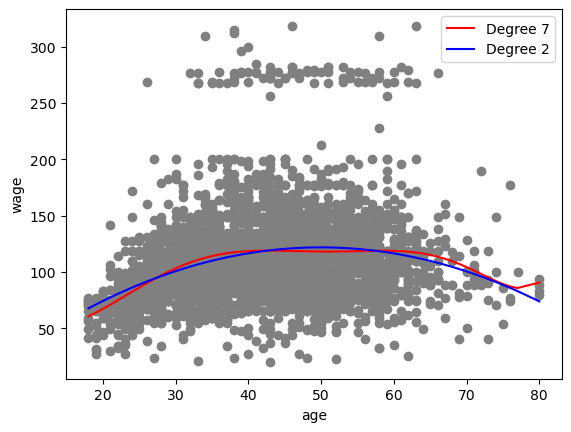

In [70]:
#Plot
reg7 = polyreg(7, Wage)
reg2 = polyreg(2, Wage)

o = np.argsort(Wage['age']) #Sort age by indices

plt.figure()
plt.scatter(age, wage, color="gray")
plt.plot(Wage["age"].iloc[o], reg7.predict(Wage).iloc[o], color="red", label="Degree 7")
plt.plot(Wage["age"].iloc[o], reg2.predict(Wage).iloc[o], color="blue", label="Degree 2")
plt.xlabel("age")
plt.ylabel("wage")
plt.legend()
plt.show()

## b)
***

In [62]:
#Step function
def stepreg(k, data):
    data = data.copy()
    data['age_cut'] = pd.cut(data['age'], k)

    return smf.ols("wage ~ age_cut", data = data).fit()

In [66]:
MSE_step = np.zeros(K - 1)

for k in range(2, K + 1):
    reg = stepreg(k, train)
    pred = reg.predict(test.assign(age_cut = pd.cut(test['age'], k)))
    MSE_step[k - 2] = np.mean((test['wage'] - pred) ** 2)

print(f"Optimal number of cuts: {np.argmin(MSE_step) + 2}")

Optimal number of cuts: 10


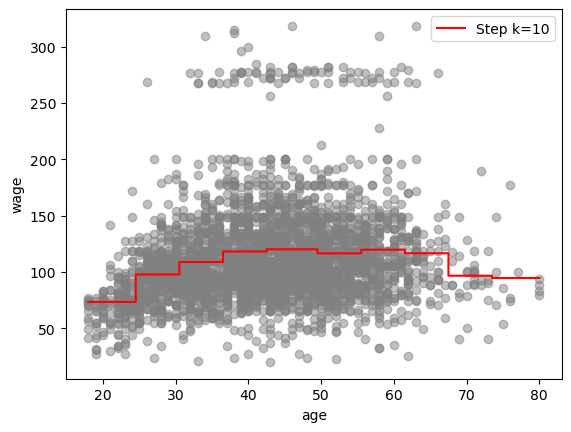

In [69]:
k_opt = np.argmin(MSE_step) + 2
reg_step = stepreg(k_opt, Wage)
pred_step = reg_step.predict(Wage.assign(age_cut = pd.cut(Wage['age'], k_opt)))

plt.figure()
plt.scatter(age, wage, color="gray", alpha=0.5)
plt.step(Wage["age"].iloc[o], pred_step.iloc[o], color="red", where="mid", label=f"Step k={k_opt}")
plt.xlabel("age")
plt.ylabel("wage")
plt.legend()
plt.show()